In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
flight_data = pd.read_csv("/content/drive/MyDrive/2026_1_AI_SOGANG_STUDY/ai_sogang_study/02_pandas/flights.csv")

In [7]:
flight_data.head()

,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


In [8]:
flight_data.describe()

,year,passengers
count,144.000000,144.000000
mean,1954.500000,280.298611
std,3.464102,119.966317
min,1949.000000,104.000000
25%,1951.750000,180.000000
50%,1954.500000,265.500000
75%,1957.250000,360.500000
max,1960.000000,622.000000


In [9]:
count_month = flight_data["month"].value_counts()
print(count_month)

month
January      12
February     12
March        12
April        12
May          12
June         12
July         12
August       12
September    12
October      12
November     12
December     12
Name: count, dtype: int64


In [10]:
grouped_year = flight_data.groupby("year")["passengers"].sum()
print(grouped_year)

year
1949    1520
1950    1676
1951    2042
1952    2364
1953    2700
1954    2867
1955    3408
1956    3939
1957    4421
1958    4572
1959    5140
1960    5714
Name: passengers, dtype: int64


In [40]:
grouped_month = flight_data.groupby("month")["passengers"].mean()
print(grouped_month)

month
April        267.083333
August       351.083333
December     261.833333
February     235.000000
January      241.750000
July         351.333333
June         311.666667
March        270.166667
May          271.833333
November     232.833333
October      266.583333
September    302.416667
Name: passengers, dtype: float64


In [13]:
count_year = flight_data["year"].value_counts()
print(count_year)

year
1949    12
1950    12
1951    12
1952    12
1953    12
1954    12
1955    12
1956    12
1957    12
1958    12
1959    12
1960    12
Name: count, dtype: int64


In [42]:
flight_data.isna().sum() # 결측값 확인

,0
year,0
month,0
passengers,0


In [17]:
flight_data.duplicated().sum() # 중복값 확인

np.int64(0)

In [18]:
flights_data = flight_data

In [19]:
flights_data.head() # 같은 정보

,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


<Axes: xlabel='year', ylabel='passengers'>

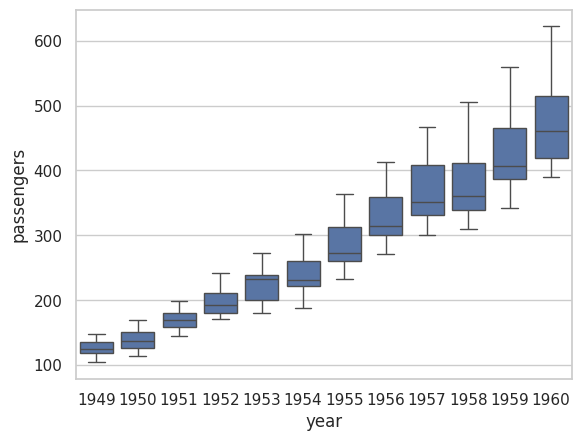

In [20]:
sns.set(style = "whitegrid")
sns.boxplot(x="year", y="passengers", data = flights_data)

In [23]:
monthly_passengers = flights_data.pivot_table(values = "passengers", index="month", columns="year")

monthly_passengers


year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
April,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
August,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
December,118.0,140.0,166.0,194.0,201.0,229.0,278.0,306.0,336.0,337.0,405.0,432.0
February,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
January,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
July,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
June,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
March,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0


<Axes: xlabel='year', ylabel='month'>

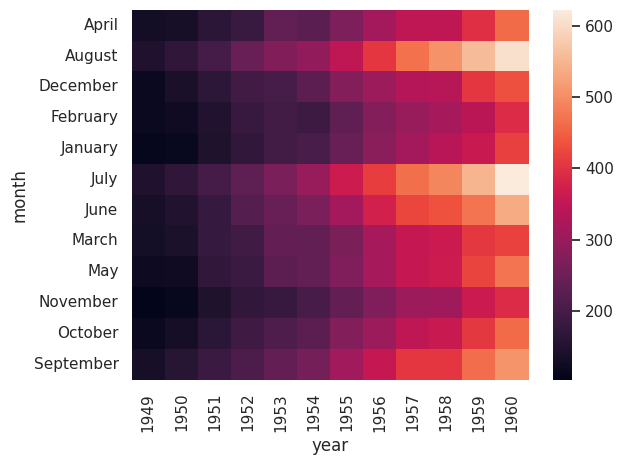

In [24]:
sns.heatmap(monthly_passengers)

<Axes: xlabel='year', ylabel='passengers'>

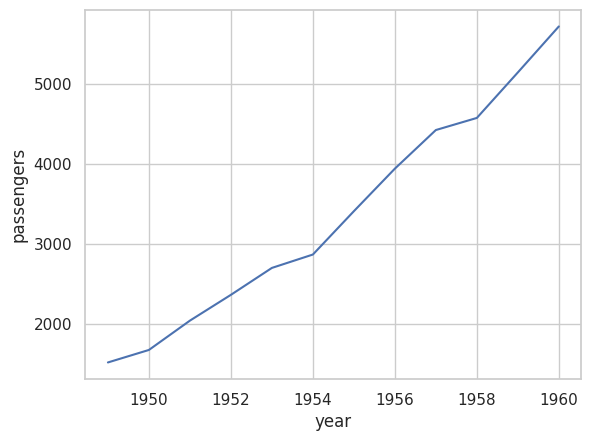

In [26]:
sns.lineplot(x="year", y = "passengers", data= flights_data.groupby("year").sum())

In [46]:
data= flights_data.groupby("year").sum()
data

,month,passengers
year,,
1949,JanuaryFebruaryMarchAprilMayJuneJulyAugustSept...,1520
1950,JanuaryFebruaryMarchAprilMayJuneJulyAugustSept...,1676
1951,JanuaryFebruaryMarchAprilMayJuneJulyAugustSept...,2042
1952,JanuaryFebruaryMarchAprilMayJuneJulyAugustSept...,2364
1953,JanuaryFebruaryMarchAprilMayJuneJulyAugustSept...,2700
1954,JanuaryFebruaryMarchAprilMayJuneJulyAugustSept...,2867
1955,JanuaryFebruaryMarchAprilMayJuneJulyAugustSept...,3408
1956,JanuaryFebruaryMarchAprilMayJuneJulyAugustSept...,3939
1957,JanuaryFebruaryMarchAprilMayJuneJulyAugustSept...,4421


In [44]:
sns.lineplot(x="year", y = "passengers", data= flights_data.groupby("year").mean())
# groupby를 하면, 기준 컬럼을 새로운 index로 하는 데이터프레임 덩어리가 임시적으로 생기고, 그걸 mean, sum 같은 집계 함수를 적용하면,
# 모든 컬럼들에 대해 해당 집계함수를 적용한 새로운 데이터프레임이 생성됨.
# 위의 예시처럼 month, passengers 컬럼에 적용됨. year는 index로 들어감.
# sum은 mont 컬럼이 억지로라도 합쳐지지만, mean의 경우는 문자를 평균낼 수는 없기 때문에 오류남.

TypeError: agg function failed [how->mean,dtype->object]

<Axes: xlabel='year', ylabel='passengers'>

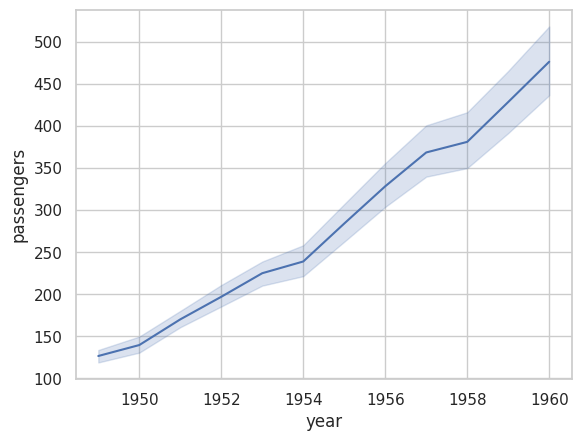

In [29]:
sns.lineplot(x="year", y = "passengers", data= flights_data)

<Axes: xlabel='month', ylabel='passengers'>

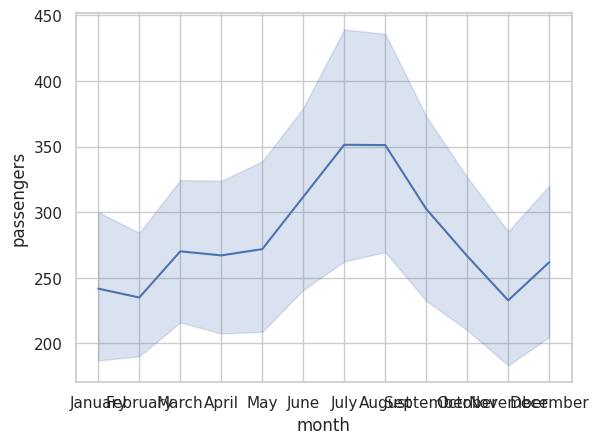

In [28]:
sns.lineplot(x="month", y = "passengers", data= flights_data)

<Axes: xlabel='month', ylabel='passengers'>

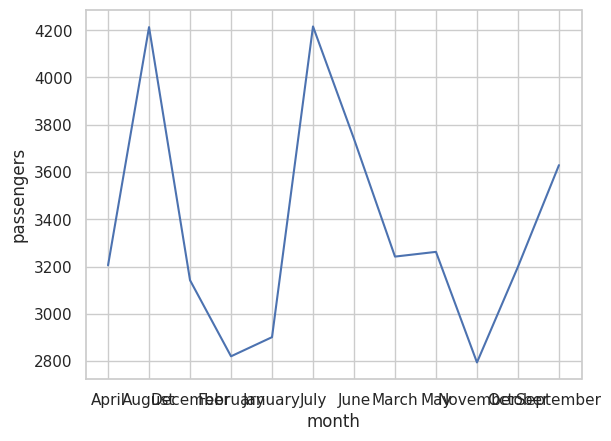

In [30]:
sns.lineplot(x="month", y = "passengers", data= flights_data.groupby("month").sum())

<Axes: xlabel='month', ylabel='passengers'>

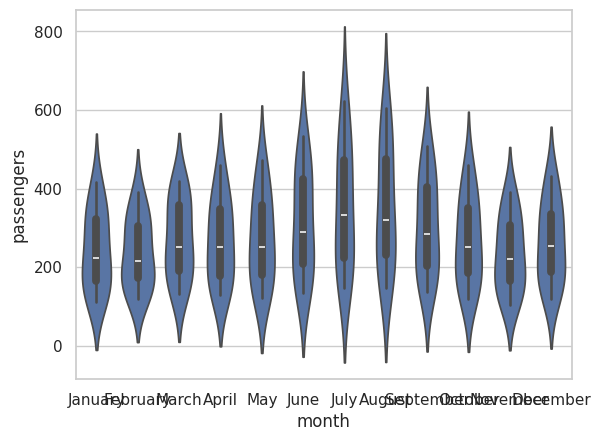

In [31]:
sns.violinplot(x="month", y = "passengers", data= flights_data)

<Axes: xlabel='month', ylabel='passengers'>

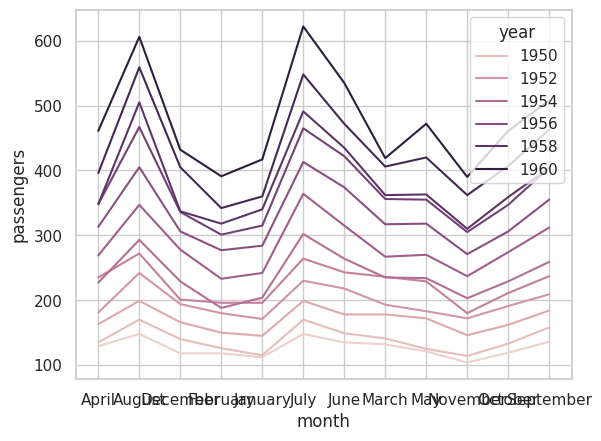

In [33]:
sns.lineplot(x="month", y="passengers", hue="year", data=flights_data.groupby(["year", "month"]).mean())

<Axes: xlabel='passengers', ylabel='Count'>

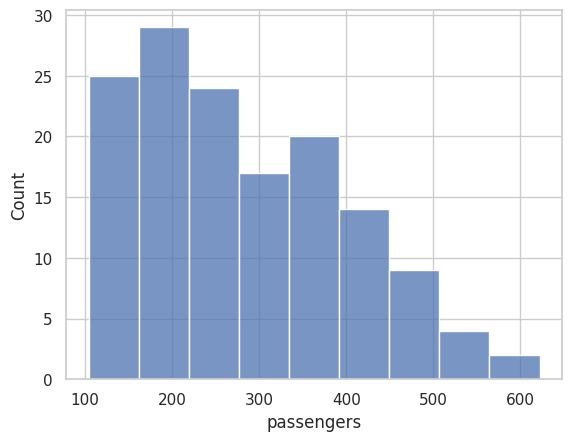

In [34]:
sns.histplot(data=flights_data, x="passengers")

<Axes: xlabel='None', ylabel='passengers'>

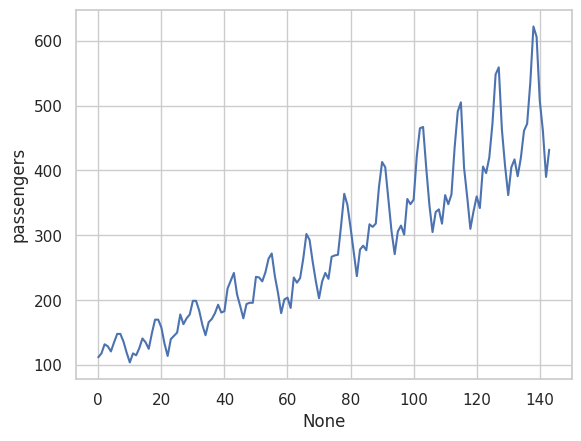

In [35]:
sns.lineplot(x=flights_data.index, y="passengers", data=flights_data)